# EDA: Amazon Reviews 2023 — Toys and Games

Цель: понять структуру датасета, оценить качество текстовых метаданных, применить 20-core фильтрацию (как в AlphaFuse), подготовить чистые данные для дальнейших экспериментов с flow matching.

## План
1. Загрузка данных (reviews + meta).
2. Базовая статистика.
3. Распределения взаимодействий.
4. Качество текстовых метаданных.
5. Временной анализ.
6. 20-core фильтрация (итеративная).
7. Подготовка текстов для TEM-энкодера.
8. Превью train/val/test split (leave-one-out и cold-start).
9. Сохранение очищенных данных.

## Источник данных
Amazon Reviews 2023, категория Toys_and_Games. Скачать с https://amazon-reviews-2023.github.io/

Нужны два файла:
- `Toys_and_Games.jsonl.gz` — взаимодействия (reviews)
- `meta_Toys_and_Games.jsonl.gz` — метаданные товаров

Положи их в `./data/raw/`.

In [2]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_colwidth', 80)

DATA_DIR = Path('../data/raw')
OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

REVIEWS_PATH = DATA_DIR / 'Toys_and_Games.jsonl'
META_PATH = DATA_DIR / 'meta_Toys_and_Games.jsonl'

print(f'Reviews exists: {REVIEWS_PATH.exists()}')
print(f'Meta exists: {META_PATH.exists()}')

Reviews exists: True
Meta exists: True


## 1. Загрузка данных

Файлы — JSONL, каждая строка — отдельный JSON-объект. Размер ~1-2 GB в распакованном виде. Читаем стримом, чтобы не падать по памяти.

Из reviews нам нужны только: `user_id`, `parent_asin` (это item ID), `timestamp`, `rating`.

Из meta нам нужны: `parent_asin`, `title`, `description`, `features`, `categories`, `store` (brand).

In [3]:
def load_jsonl(path, fields=None, limit=None):
    """Стриминговая загрузка JSONL. fields — какие поля оставить."""
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            obj = json.loads(line)
            if fields:
                obj = {k: obj.get(k) for k in fields}
            rows.append(obj)
    return rows

# Сначала загрузим первые 100 строк, чтобы посмотреть на схему
sample_reviews = load_jsonl(REVIEWS_PATH, limit=5)
sample_meta = load_jsonl(META_PATH, limit=5)

print('Reviews fields:', list(sample_reviews[0].keys()))
print()
print('Meta fields:', list(sample_meta[0].keys()))

Reviews fields: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Meta fields: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


In [4]:
# Пример reviews
print('Review example:')
for k, v in sample_reviews[0].items():
    v_str = str(v)[:200]
    print(f'  {k}: {v_str}')

print()
print('Meta example:')
for k, v in sample_meta[0].items():
    v_str = str(v)[:200]
    print(f'  {k}: {v_str}')

Review example:
  rating: 5.0
  title: Granddaughters love them!
  text: I purchased several of these for my granddaughters for Xmas & they absolutely love them. In fact so do their brothers. Lol. Be aware that there are tiny magnets in them so that you can perch the ppl o
  images: []
  asin: B09QH7QJS7
  parent_asin: B09QH7QJS7
  user_id: AFKZENTNBQ7A7V7UXW5JJI6UGRYQ
  timestamp: 1677939664713
  helpful_vote: 0
  verified_purchase: True

Meta example:
  main_category: Toys & Games
  title: KUNGOON Happy Anniversary Balloon Banner,Wedding Anniversary Party Decorations,Love Party and Anniversary Party Supplies,16 Inch Gold Aluminum Foil.
  average_rating: 4.5
  rating_number: 241
  features: []
  description: []
  price: None
  images: [{'thumb': 'https://m.media-amazon.com/images/I/41enwmDCoZL._AC_US40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41enwmDCoZL._AC_.jpg', 'variant': 'MAIN', 'hi_res': 'https://m.media-amazon.co
  videos: [{'title': 'Pretty Cool!', 'url': 'https://

In [5]:
# Полная загрузка. Это может занять 1-3 минуты для Toys.
REVIEW_FIELDS = ['user_id', 'parent_asin', 'timestamp', 'rating']
META_FIELDS = ['parent_asin', 'title', 'description', 'features', 'categories', 'store', 'main_category']

%time reviews_raw = load_jsonl(REVIEWS_PATH, fields=REVIEW_FIELDS)
%time meta_raw = load_jsonl(META_PATH, fields=META_FIELDS)

print(f'Reviews: {len(reviews_raw):,}')
print(f'Meta: {len(meta_raw):,}')

CPU times: total: 54.4 s
Wall time: 56.1 s
CPU times: total: 18.1 s
Wall time: 18.4 s
Reviews: 16,260,406
Meta: 890,874


In [6]:
reviews = pd.DataFrame(reviews_raw)
meta = pd.DataFrame(meta_raw)

del reviews_raw, meta_raw

# Timestamp в миллисекундах, конвертируем
reviews['timestamp'] = pd.to_datetime(reviews['timestamp'], unit='ms')
reviews.head()

,user_id,parent_asin,timestamp,rating
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B09QH7QJS7,2023-03-04 14:21:04.713,5.0
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B06XYKSKQP,2021-12-18 19:20:30.760,3.0
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07XRSD5R9,2020-02-06 00:41:59.154,5.0
3,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B007JWWUDW,2016-08-18 17:49:48.000,5.0
4,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B00MZG6OO8,2016-08-18 17:39:56.000,3.0


In [18]:
meta.head()

,parent_asin,title,description,features,categories,store,main_category
0,B08GPM7CQN,"KUNGOON Happy Anniversary Balloon Banner,Wedding Anniversary Party Decoratio...",[],[],[],Kunggo,Toys & Games
1,B09X9XW42H,"Gothic Mothman Plushie Doll with Bright Red Eyes, Medieval Style Attractive ...",[🦋 Description: Mothman’s bright red eyes could stare you down in an instant...,"[🦋 Mothman’s bright red eyes could stare you down in an instant, and his hug...","[Toys & Games, Stuffed Animals & Plush Toys, Plush Figures]",Felicy,Toys & Games
2,B01I9QET6M,Melody Jane Dollhouse Builders DIY 1:24 Scale Classic White Plastic Georgian...,[],[1:24 Scale - Plastic - Approximate cut out size - width 38mm - height 48mm ...,"[Toys & Games, Dolls & Accessories, Dollhouse Accessories, Décor]",Melody Jane Dolls Houses,Toys & Games
3,B019XEEX1A,"Traxxas Stampede 4X4: 1/10 Scale 4wd Monster Truck, Red",[Stampede 4X4 is built Traxxas Tough to withstand all the 4WD mayhem you can...,"[Waterproof electronics for all-weather driving excitement in water, mud and...","[Toys & Games, Remote & App Controlled Vehicles & Parts, Remote & App Contro...",Traxxas,Toys & Games
4,B09G7K3JWQ,Hot Wheels Monster Truck 1:24 Scale 2022 Bone Shaker It All Vehicle with Gia...,[The Hot Wheels Monster Trucks 1:24 scale die-cast trucks are THE baddest tr...,"[Designed in 1:24 scale with durable die-cast metal bodies, Hot Wheels Monst...","[Toys & Games, Preschool, Pre-Kindergarten Toys]",Hot Wheels,Toys & Games


## 2. Базовая статистика

Считаем число уникальных пользователей, товаров, взаимодействий. Sparsity — стандартная метрика разреженности.

In [8]:
def basic_stats(df, name='Dataset'):
    n_users = df['user_id'].nunique()
    n_items = df['parent_asin'].nunique()
    n_inter = len(df)
    sparsity = 1.0 - n_inter / (n_users * n_items)
    print(f'{name}:')
    print(f'  Users:        {n_users:>12,}')
    print(f'  Items:        {n_items:>12,}')
    print(f'  Interactions: {n_inter:>12,}')
    print(f'  Sparsity:     {sparsity*100:>11.4f}%')
    print(f'  Avg inter/user: {n_inter/n_users:>10.2f}')
    print(f'  Avg inter/item: {n_inter/n_items:>10.2f}')

basic_stats(reviews, 'Raw reviews')

Raw reviews:
  Users:           8,116,226
  Items:             890,667
  Interactions:   16,260,406
  Sparsity:         99.9998%
  Avg inter/user:       2.00
  Avg inter/item:      18.26


In [9]:
# Сколько товаров в meta, для скольких есть взаимодействия
meta_items = set(meta['parent_asin'])
inter_items = set(reviews['parent_asin'])
print(f'Items in meta:               {len(meta_items):>10,}')
print(f'Items in interactions:       {len(inter_items):>10,}')
print(f'Items in both:               {len(meta_items & inter_items):>10,}')
print(f'Items in inter but not meta: {len(inter_items - meta_items):>10,}')
print(f'Items in meta but not inter: {len(meta_items - inter_items):>10,}')

Items in meta:                  890,874
Items in interactions:          890,667
Items in both:                  890,667
Items in inter but not meta:          0
Items in meta but not inter:        207


In [10]:
# Дедупликация: один пользователь мог оставить несколько отзывов на один товар
before = len(reviews)
reviews = reviews.sort_values('timestamp').drop_duplicates(['user_id', 'parent_asin'], keep='first')
after = len(reviews)
print(f'Дубликатов user-item: {before - after:,} ({(before-after)/before*100:.2f}%)')

# Убираем взаимодействия с товарами без метаданных — нам нужны тексты для всех
before = len(reviews)
reviews = reviews[reviews['parent_asin'].isin(meta_items)]
after = len(reviews)
print(f'Удалено взаимодействий без meta: {before - after:,}')

basic_stats(reviews, 'After dedup + meta filter')

Дубликатов user-item: 207,966 (1.28%)
Удалено взаимодействий без meta: 0
After dedup + meta filter:
  Users:           8,116,226
  Items:             890,667
  Interactions:   16,052,440
  Sparsity:         99.9998%
  Avg inter/user:       1.98
  Avg inter/item:      18.02


## 3. Распределения взаимодействий

Hard fact из рекомендаций: распределение взаимодействий long-tail. Хотим увидеть распределение в log-log.

In [11]:
user_counts = reviews['user_id'].value_counts()
item_counts = reviews['parent_asin'].value_counts()

print('Interactions per user:')
print(user_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
print()
print('Interactions per item:')
print(item_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

Interactions per user:
count    8.116226e+06
mean     1.977821e+00
std      3.480502e+00
min      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      4.000000e+00
95%      5.000000e+00
99%      1.200000e+01
max      2.891000e+03
Name: count, dtype: float64

Interactions per item:
count    890667.000000
mean         18.022942
std          94.292767
min           1.000000
50%           3.000000
75%          10.000000
90%          31.000000
95%          65.000000
99%         256.000000
max       18484.000000
Name: count, dtype: float64


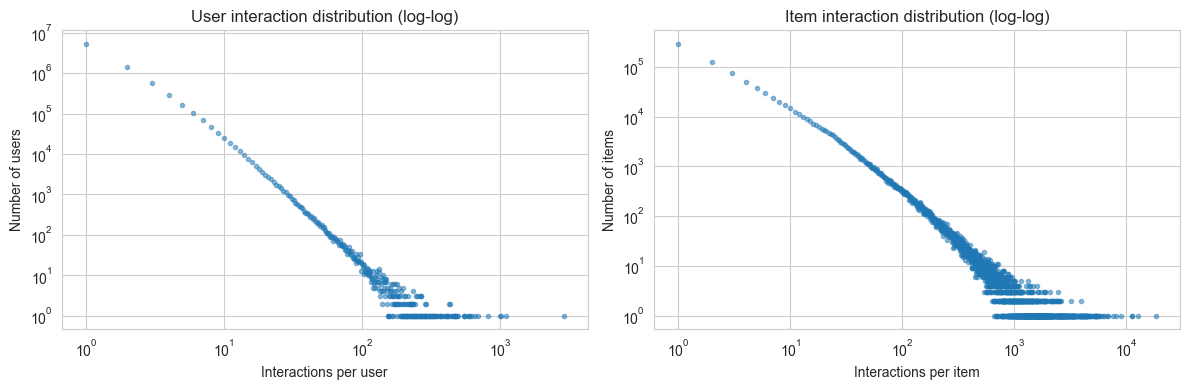

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма в log-log
ax = axes[0]
user_freq = user_counts.value_counts().sort_index()
ax.loglog(user_freq.index, user_freq.values, 'o', markersize=3, alpha=0.5)
ax.set_xlabel('Interactions per user')
ax.set_ylabel('Number of users')
ax.set_title('User interaction distribution (log-log)')

ax = axes[1]
item_freq = item_counts.value_counts().sort_index()
ax.loglog(item_freq.index, item_freq.values, 'o', markersize=3, alpha=0.5)
ax.set_xlabel('Interactions per item')
ax.set_ylabel('Number of items')
ax.set_title('Item interaction distribution (log-log)')

plt.tight_layout()
plt.show()

In [13]:
# Сколько пользователей и товаров останется при разных порогах k-core
thresholds = [3, 5, 10, 15, 20, 30, 50]
print(f'{"k":>4} {"#users":>10} {"#items":>10} {"#inter":>12}')
for k in thresholds:
    u_keep = user_counts[user_counts >= k].index
    i_keep = item_counts[item_counts >= k].index
    mask = reviews['user_id'].isin(u_keep) & reviews['parent_asin'].isin(i_keep)
    n_u = reviews.loc[mask, 'user_id'].nunique()
    n_i = reviews.loc[mask, 'parent_asin'].nunique()
    n_int = mask.sum()
    print(f'{k:>4} {n_u:>10,} {n_i:>10,} {n_int:>12,}')

# Это только первый проход. Реальная k-core требует итераций — см. дальше.

   k     #users     #items       #inter
   3  1,417,716    456,801    7,655,453
   5    555,547    330,816    4,726,123
  10    138,621    202,553    2,128,136
  15     57,840    144,984    1,222,852
  20     30,627    110,666      783,081
  30     12,233     69,801      374,146
  50      3,848     35,472      137,319


## 4. Качество текстовых метаданных

Принципиально для нашей задачи: тексты должны быть осмысленными для каждого товара. Проверяем пропуски, длины, наличие полезных полей.

In [14]:
def field_stats(df, field):
    """Статистика по текстовому полю: пропуски, пустые, длины."""
    s = df[field]
    null_cnt = s.isna().sum()
    
    def is_empty(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return True
        if isinstance(v, str):
            return v.strip() == ''
        if isinstance(v, (list, tuple)):
            return len(v) == 0 or all(not str(x).strip() for x in v)
        return False
    
    empty_cnt = s.apply(is_empty).sum()
    
    def to_text(v):
        if is_empty(v):
            return ''
        if isinstance(v, (list, tuple)):
            return ' '.join(str(x) for x in v)
        return str(v)
    
    texts = s.apply(to_text)
    lens = texts.str.len()
    
    print(f'{field}:')
    print(f'  Null: {null_cnt:,} ({null_cnt/len(df)*100:.1f}%)')
    print(f'  Empty (incl null): {empty_cnt:,} ({empty_cnt/len(df)*100:.1f}%)')
    print(f'  Length: mean={lens.mean():.0f}, median={lens.median():.0f}, max={lens.max():,}')

for f in ['title', 'description', 'features', 'categories', 'store']:
    field_stats(meta, f)
    print()

title:
  Null: 0 (0.0%)
  Empty (incl null): 37 (0.0%)
  Length: mean=98, median=85, max=1,143

description:
  Null: 0 (0.0%)
  Empty (incl null): 305,664 (34.3%)
  Length: mean=354, median=175, max=36,847

features:
  Null: 0 (0.0%)
  Empty (incl null): 176,999 (19.9%)
  Length: mean=462, median=250, max=6,367

categories:
  Null: 0 (0.0%)
  Empty (incl null): 88,952 (10.0%)
  Length: mean=54, median=50, max=149

store:
  Null: 5,357 (0.6%)
  Empty (incl null): 5,360 (0.6%)
  Length: mean=9, median=8, max=165



In [15]:
# Посмотрим примеры description и features
sample = meta.sample(3, random_state=42)
for _, row in sample.iterrows():
    print(f'ASIN: {row["parent_asin"]}')
    print(f'Title: {row["title"]}')
    print(f'Description: {row["description"]}')
    print(f'Features: {row["features"]}')
    print(f'Categories: {row["categories"]}')
    print(f'Store: {row["store"]}')
    print('-' * 80)

ASIN: B00T8SEDBC
Title: Bandai Shuriken Sentai Ninninger Nin Shuriken Series 05 Momoninger Shuriken
Description: ['This item is Brand new & factory sealed.']
Features: ['Japanimport', '(C) 2015 TV Asahi, Toei AG, Toei']
Categories: ['Toys & Games', 'Preschool', 'Pre-Kindergarten Toys']
Store: BANDAI NAMCO Entertainment
--------------------------------------------------------------------------------
ASIN: B01B6DR8QI
Title: MasterPieces Animal Planet Bengal Tiger 1000 Piece Jigsaw Puzzle by Carl Brenders
Description: ['Product Description', "This MasterPieces Animal Planet 19.25 inch x 26.75 inch 1000 piece puzzle is not only fun, but also educational, with animal fun facts on every box! Watch your favorite animals come to life in with this incredible painting by artist Carl Brenders. Brenders has an eye for depicting even the smallest details, and this ability has helped him capture the hearts of puzzlers and art lovers everywhere. With the Bengal Tiger's fierce eyes and intense stare, 

## 5. Временной анализ

Важно для разбиения train/val/test: понять, как распределены взаимодействия по времени. Для leave-one-out и cold-start split нужно сортировать по времени.

Time range: 1998-10-18 04:01:50 -> 2023-09-13 02:18:35.517000
Span: 9095 days


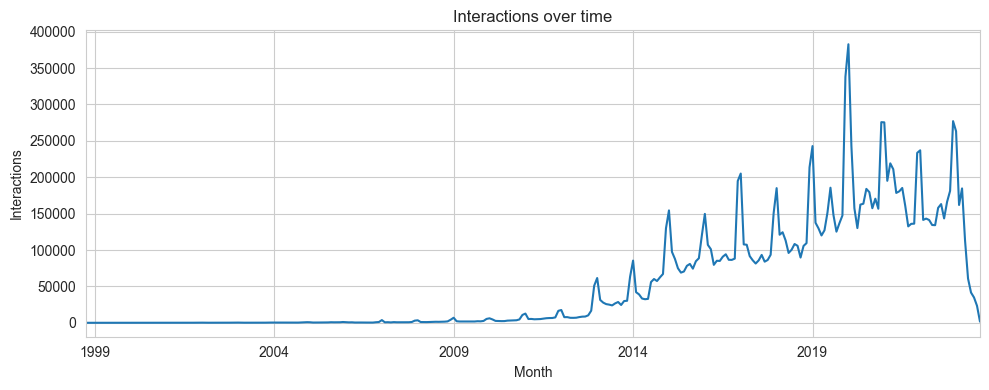

In [16]:
print(f'Time range: {reviews["timestamp"].min()} -> {reviews["timestamp"].max()}')
print(f'Span: {(reviews["timestamp"].max() - reviews["timestamp"].min()).days} days')

fig, ax = plt.subplots(figsize=(10, 4))
reviews['timestamp'].dt.to_period('M').value_counts().sort_index().plot(ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Interactions')
ax.set_title('Interactions over time')
plt.tight_layout()
plt.show()

## 6. 20-core фильтрация (итеративная)

AlphaFuse использует 20-core: каждый user и каждый item должны иметь минимум 20 взаимодействий. Это нужно делать **итеративно**: удаление редких users может сделать некоторые items редкими, и наоборот.

Останавливаемся, когда за итерацию ничего не удалилось.

In [17]:
def k_core_filter(df, k_user=20, k_item=20, max_iters=20, verbose=True):
    """Итеративная k-core фильтрация."""
    df = df.copy()
    for it in range(max_iters):
        uc = df['user_id'].value_counts()
        ic = df['parent_asin'].value_counts()
        users_keep = uc[uc >= k_user].index
        items_keep = ic[ic >= k_item].index
        before = len(df)
        df = df[df['user_id'].isin(users_keep) & df['parent_asin'].isin(items_keep)]
        after = len(df)
        if verbose:
            print(f'Iter {it+1}: {before:,} -> {after:,} ({df["user_id"].nunique():,} users, {df["parent_asin"].nunique():,} items)')
        if before == after:
            break
    return df

reviews_20core = k_core_filter(reviews, k_user=20, k_item=20)
basic_stats(reviews_20core, '20-core filtered')

Iter 1: 16,052,440 -> 783,081 (30,627 users, 110,666 items)
Iter 2: 783,081 -> 204,295 (18,219 users, 6,866 items)
Iter 3: 204,295 -> 41,497 (1,647 users, 4,538 items)
Iter 4: 41,497 -> 6,481 (1,005 users, 305 items)
Iter 5: 6,481 -> 208 (14 users, 99 items)
Iter 6: 208 -> 0 (0 users, 0 items)
Iter 7: 0 -> 0 (0 users, 0 items)


ZeroDivisionError: division by zero

In [19]:
# Сравним с тем, что заявлено в AlphaFuse Table 1 для Toys:
# users: 19,412, items: 11,924, interactions: 138,444
# Возможно понадобится подкрутить фильтры — AlphaFuse мог использовать чуть другие правила.
# Например, фильтр по самой длинной последовательности или по rating.

print('Expected (AlphaFuse): 19,412 users / 11,924 items / 138,444 interactions')
print('Если числа сильно расходятся — стоит посмотреть код AlphaFuse:')
print('  https://github.com/Hugo-Chinn/AlphaFuse')

Expected (AlphaFuse): 19,412 users / 11,924 items / 138,444 interactions
Если числа сильно расходятся — стоит посмотреть код AlphaFuse:
  https://github.com/Hugo-Chinn/AlphaFuse


In [ ]:
# Распределения после фильтрации
uc = reviews_20core['user_id'].value_counts()
ic = reviews_20core['parent_asin'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(uc.values, bins=50, log=True)
axes[0].set_xlabel('Interactions per user')
axes[0].set_ylabel('Users (log)')
axes[0].set_title(f'After 20-core: users (median={uc.median():.0f})')

axes[1].hist(ic.values, bins=50, log=True)
axes[1].set_xlabel('Interactions per item')
axes[1].set_ylabel('Items (log)')
axes[1].set_title(f'After 20-core: items (median={ic.median():.0f})')
plt.tight_layout()
plt.show()

## 7. Подготовка текстов для TEM-энкодера

Конкатенируем поля в один текст на товар. Формат как у AlphaFuse / iDreamRec: title + description + features + categories + store.

Подсчитываем количество токенов — это важно для оценки стоимости OpenAI API (`text-embedding-3-small`).

In [ ]:
def stringify(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return ''
    if isinstance(v, (list, tuple)):
        return ' '.join(str(x) for x in v if x is not None and str(x).strip())
    return str(v).strip()

def build_item_text(row):
    parts = []
    if (t := stringify(row.get('title'))):
        parts.append(f'Title: {t}')
    if (s := stringify(row.get('store'))):
        parts.append(f'Brand: {s}')
    if (c := stringify(row.get('categories'))):
        parts.append(f'Categories: {c}')
    if (f := stringify(row.get('features'))):
        parts.append(f'Features: {f}')
    if (d := stringify(row.get('description'))):
        parts.append(f'Description: {d}')
    return '. '.join(parts)

# Только товары, оставшиеся после 20-core
kept_items = set(reviews_20core['parent_asin'])
meta_kept = meta[meta['parent_asin'].isin(kept_items)].copy()
meta_kept['text'] = meta_kept.apply(build_item_text, axis=1)

print(f'Items with text: {len(meta_kept):,}')
print()
print('Sample texts:')
for t in meta_kept['text'].sample(3, random_state=42).values:
    print(t[:500])
    print('-' * 80)

In [ ]:
# Длина текстов в символах
text_lens = meta_kept['text'].str.len()
print('Text length (chars):')
print(text_lens.describe(percentiles=[0.5, 0.9, 0.99]))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(text_lens, bins=80, log=True)
ax.set_xlabel('Text length (chars)')
ax.set_ylabel('Items (log)')
ax.set_title('Item text length distribution')
plt.tight_layout()
plt.show()

# Сколько пустых?
n_empty = (meta_kept['text'].str.len() < 20).sum()
print(f'\nItems with very short text (<20 chars): {n_empty:,} ({n_empty/len(meta_kept)*100:.2f}%)')

In [ ]:
# Оценка количества токенов для OpenAI API. Без точного токенизатора берём прикидку 
# 1 токен ≈ 4 символа для английского.
# Точно посчитать можно через tiktoken (uncomment если установлен):
# import tiktoken
# enc = tiktoken.encoding_for_model('text-embedding-3-small')
# tokens = meta_kept['text'].apply(lambda x: len(enc.encode(x)))

approx_tokens = (meta_kept['text'].str.len() / 4).clip(upper=8191)  # лимит модели
total_tokens = approx_tokens.sum()
print(f'Approx total tokens: {total_tokens:,.0f}')
print(f'OpenAI text-embedding-3-small cost: ${total_tokens / 1e6 * 0.02:.4f}')
print(f'OpenAI text-embedding-3-large cost: ${total_tokens / 1e6 * 0.13:.4f}')

## 8. Превью train/val/test split

В AlphaFuse есть два режима:
- **Leave-one-out**: последнее взаимодействие каждого пользователя — test, предпоследнее — val, остальное — train.
- **Cold-start**: пользователи сортируются по времени последнего взаимодействия, последние 10% — test users, следующие 10% — val users, остальные — train users.

Cold-start строже: test-пользователей нет в train, что лучше проверяет генерализацию.

Для каждого пользователя берём максимум 10 последних взаимодействий как историю (фиксированная длина для seq-rec моделей).

In [ ]:
MAX_SEQ_LEN = 10

def build_sequences(df, max_len=MAX_SEQ_LEN):
    """Для каждого пользователя возвращаем хронологическую последовательность items."""
    seqs = (df.sort_values('timestamp')
              .groupby('user_id')['parent_asin']
              .apply(list)
              .reset_index())
    seqs.columns = ['user_id', 'item_seq']
    # Берём последние max_len + 1 (история до 10 + таргет)
    seqs['item_seq'] = seqs['item_seq'].apply(lambda x: x[-(max_len + 1):])
    seqs['seq_len'] = seqs['item_seq'].apply(len)
    return seqs

# Время последнего взаимодействия каждого пользователя (для cold-start split)
user_last_ts = reviews_20core.groupby('user_id')['timestamp'].max().reset_index()
user_last_ts.columns = ['user_id', 'last_ts']
user_last_ts = user_last_ts.sort_values('last_ts').reset_index(drop=True)

n = len(user_last_ts)
train_users = set(user_last_ts.iloc[: int(n * 0.8)]['user_id'])
val_users = set(user_last_ts.iloc[int(n * 0.8): int(n * 0.9)]['user_id'])
test_users = set(user_last_ts.iloc[int(n * 0.9):]['user_id'])

print(f'Cold-start split: {len(train_users):,} train / {len(val_users):,} val / {len(test_users):,} test users')

sequences = build_sequences(reviews_20core)
print(f'\nSequence length distribution:')
print(sequences['seq_len'].describe())

In [ ]:
# Пример: одна тренировочная и одна тестовая последовательность
train_seq_sample = sequences[sequences['user_id'].isin(train_users)].sample(1, random_state=0).iloc[0]
test_seq_sample = sequences[sequences['user_id'].isin(test_users)].sample(1, random_state=0).iloc[0]

def show_seq(seq_row, meta_df, label):
    print(f'=== {label} ===')
    print(f'User: {seq_row["user_id"]}')
    titles = meta_df.set_index('parent_asin').reindex(seq_row['item_seq'])['title'].fillna('<no title>')
    for i, (asin, title) in enumerate(zip(seq_row['item_seq'], titles)):
        mark = '>>> TARGET' if i == len(seq_row['item_seq']) - 1 else '         '
        print(f'  {mark} [{i+1}] {asin}: {title[:80]}')
    print()

show_seq(train_seq_sample, meta_kept, 'TRAIN example')
show_seq(test_seq_sample, meta_kept, 'TEST example (cold-start)')

## 9. Сохранение очищенных данных

Сохраняем в parquet — компактно, быстро читается.

Что сохраняем:
- `interactions.parquet` — отфильтрованные взаимодействия 20-core.
- `items.parquet` — метаданные товаров + готовый текст.
- `sequences.parquet` — последовательности по пользователям.
- `splits.json` — какие user_id в каком сплите.

In [ ]:
reviews_20core.to_parquet(OUT_DIR / 'interactions.parquet', index=False)
meta_kept[['parent_asin', 'title', 'text']].to_parquet(OUT_DIR / 'items.parquet', index=False)

# sequences — список items в list-колонке, parquet это поддерживает
sequences.to_parquet(OUT_DIR / 'sequences.parquet', index=False)

splits = {
    'train_users': sorted(train_users),
    'val_users': sorted(val_users),
    'test_users': sorted(test_users),
}
with open(OUT_DIR / 'splits.json', 'w') as f:
    json.dump(splits, f)

print('Saved:')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p}  ({p.stat().st_size / 1024 / 1024:.2f} MB)')

## Следующие шаги

1. **Проверить расхождение со статистикой AlphaFuse.** Если #users/#items сильно отличаются — посмотреть [их код](https://github.com/Hugo-Chinn/AlphaFuse) и подкрутить препроцессинг.
2. **Получить TEM-эмбеддинги** через OpenAI API (отдельный скрипт, не ноутбук — это долгий процесс с retry-логикой).
3. **Whitening эмбеддингов** — вычислить μ, Σ, W из training items, применить ко всем.
4. **Sanity check эмбеддингов** — посмотреть, что похожие по тексту товары близки в эмбеддинговом пространстве (косинус, t-SNE).
5. **Реализация baseline FM** — denoiser + transformer encoder + retrieval.

In [20]:
stats = pd.read_pickle('../data/ATG/data_statis.df')
stats

,seq_size,item_num
0,10,11924


In [27]:
train_data = pd.read_pickle('../data/ATG/train_data.df')
train_data

,seq,len_seq,next
0,"[11924, 11924, 11924, 11924, 11924, 9416, 3110, 870, 269, 402]",5,663
1,"[11924, 11924, 11924, 11924, 11924, 4270, 1328, 6379, 6922, 5908]",5,2682
2,"[11924, 7292, 7305, 7335, 7307, 6560, 7050, 9623, 9746, 7745]",9,10065
3,"[11924, 11924, 11924, 11924, 11924, 7887, 6278, 11298, 10209, 4296]",5,8263
4,"[11924, 11924, 11924, 11924, 11924, 11924, 3269, 1096, 1873, 8119]",4,8460
...,...,...,...
15524,"[11924, 11924, 11924, 11924, 11924, 2440, 5424, 7416, 4863, 3285]",5,11122
15525,"[11924, 11924, 11924, 11924, 11924, 3634, 3641, 3746, 2272, 2129]",5,6217
15526,"[11924, 11924, 11924, 11924, 11924, 9692, 8441, 5823, 3760, 3804]",5,8442
15527,"[11924, 11924, 11924, 11924, 11924, 337, 1846, 4457, 4812, 4949]",5,11559


In [31]:
train_data['len_seq'].describe()

count    15529.000000
mean         6.124606
std          2.235404
min          4.000000
25%          4.000000
50%          5.000000
75%          8.000000
max         10.000000
Name: len_seq, dtype: float64

In [23]:
emb = pd.read_pickle('../data/ATG/3large_emb.pickle')

In [35]:
type(emb)

numpy.ndarray